In [1]:
import sleap
import sys
import json
import os
import pandas as pd
import joblib
from matplotlib import animation

sys.path.append('..')
sys.path.append('/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/')
from python.polygon_based_correction import *
# from python.animation import *
from eval.eval import *
# from python.dataset_conversion import *
# from python.misprediction_classifier import *
from autoencoder.src.data_loader import *
from interpolate import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


# Load data

In [2]:
pred_result_folder = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/correction/results'
pred_result_path = os.path.join(pred_result_folder, 'pred_results_w_first_frame_v1.npy')
pred_result = np.load(pred_result_path)
print(pred_result.shape)

corrected_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_20s_no_scores_corrected.slp'
corrected_dataset = sleap.load_file(corrected_dataset_path)
print(corrected_dataset)
gt_pts = get_all_untracked_points(corrected_dataset, interpolate=False, use_labeled_only=True)

(3000, 17, 2)
Labels(labeled_frames=3000, videos=1, skeletons=1, tracks=0)
all_untracked_points shape: (3000, 17, 2)


3000it [00:03, 991.58it/s]


Missing point count: 0
reorder_idx.shape: (17,)


In [3]:
pred_missing_mask = get_missing_count(pred_result)
print(f'missing count: {np.sum(pred_missing_mask)}')

missing count: 9107.0


# Pre-align/interpolate

1. For each non-missing point, find its nearest neighbor (?) in the previous frame. Assign ID. 
    - greedy/hangarian?
2. Non-assigned IDs are missing in the current frame. Use coordinates from the previous frame as place holder.
    - still labeled as missing
    - assume no missing points in the first frame

In [4]:
def assign_ids(pred_pts, dist_thres=5):
    pred_pts = pred_pts[:, :, :2]
    frame_cnt, pt_cnt = pred_pts.shape[:2]
    id_pts = np.zeros((frame_cnt, pt_cnt, 2))
    missing_mask = np.zeros((frame_cnt, pt_cnt), dtype=bool)
    id_pts[0] = pred_pts[0]
    
    for frame_idx in range(1, frame_cnt):
        gt_curr_frame_pts = gt_pts[frame_idx]
        dist_queue = [] # (dist, pt_idx, nn_idx)
        used_nn = []
        
        for pt_idx in range(pt_cnt):
            curr_pt = pred_pts[frame_idx, pt_idx]
            dists = np.linalg.norm(gt_curr_frame_pts - curr_pt, axis=1)
            min_dist_idx = np.argmin(dists)
            dist_queue.append((dists[min_dist_idx], pt_idx, min_dist_idx))
            
        dist_queue.sort(key=lambda x: x[0])
        
        for dist, pt_idx, nn_idx in dist_queue:
            if dist > dist_thres:
                break
            if nn_idx not in used_nn:
                used_nn.append(nn_idx)
                id_pts[frame_idx, nn_idx] = gt_curr_frame_pts[pt_idx]
        
        for pt_idx in range(pt_cnt):
            if id_pts[frame_idx, pt_idx].sum() == 0:
                id_pts[frame_idx, pt_idx] = id_pts[frame_idx - 1, pt_idx]
                missing_mask[frame_idx, pt_idx] = 1
                
    return id_pts, missing_mask

In [5]:
pred_result_w_ids, id_missing_mask = assign_ids(pred_result)
print(pred_result_w_ids.shape, id_missing_mask.shape)

(3000, 17, 2) (3000, 17)


In [6]:
print(np.isclose(pred_result_w_ids[0], gt_pts[0], atol=1e-3).all())

True


# Interpolate

In [11]:
pred_result_interpolated = avg_flow_interpolate(pred_result_w_ids, window_size=4, verbose=False, non_missing_mask=~id_missing_mask)

In [15]:
result_dir = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/correction/results'
pred_id_path = os.path.join(result_dir, 'pred_results_w_ids.npy')
np.save(pred_id_path, pred_result_w_ids)

In [17]:
pred_result_w_ids.shape

(3000, 17, 2)

In [7]:
pred_result_polar_interpolated = polar_interpolate(pred_result_w_ids, verbose=False, non_missing_mask=~id_missing_mask)

In [12]:
pred_interp_missing_mask = get_missing_count(pred_result_interpolated)
print(f'missing count: {np.sum(pred_interp_missing_mask)}')

missing count: 0.0


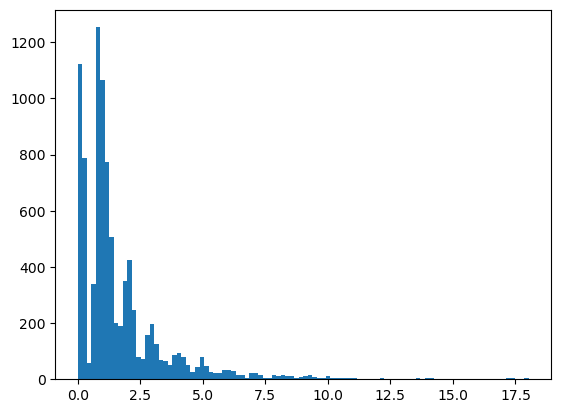

mean: 1.71673945605826, std: 2.024537088342878, max: 18.02803547094674


In [10]:
all_err = []
pred_result_interpolated = pred_result_w_ids
frame_cnt, pt_cnt = pred_result_interpolated.shape[:2]
for frame_idx in range(frame_cnt):
    for pt_idx in range(pt_cnt):
        if id_missing_mask[frame_idx, pt_idx] == 1:
            min_dist = np.min(np.linalg.norm(pred_result_interpolated[frame_idx, pt_idx] - gt_pts[frame_idx], axis=1))
            all_err.append(min_dist)
all_err = np.array(all_err)
plt.hist(all_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_err)}, std: {np.std(all_err)}, max: {np.max(all_err)}')


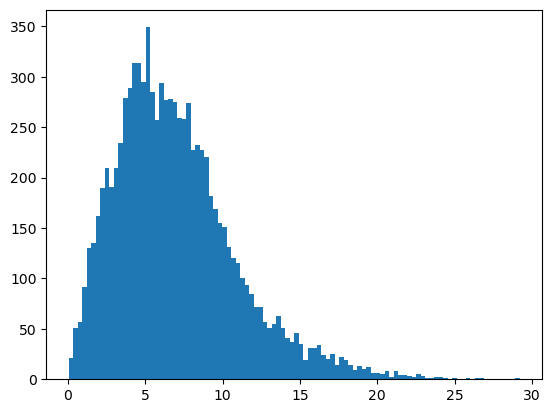

mean: 6.989386024742587, std: 3.9161639162810635, max: 29.212229725816343


In [8]:
all_err = []
pred_result_interpolated = pred_result_polar_interpolated
frame_cnt, pt_cnt = pred_result_interpolated.shape[:2]
for frame_idx in range(frame_cnt):
    for pt_idx in range(pt_cnt):
        if id_missing_mask[frame_idx, pt_idx] == 1:
            min_dist = np.min(np.linalg.norm(pred_result_interpolated[frame_idx, pt_idx] - gt_pts[frame_idx], axis=1))
            all_err.append(min_dist)
all_err = np.array(all_err)
plt.hist(all_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_err)}, std: {np.std(all_err)}, max: {np.max(all_err)}')


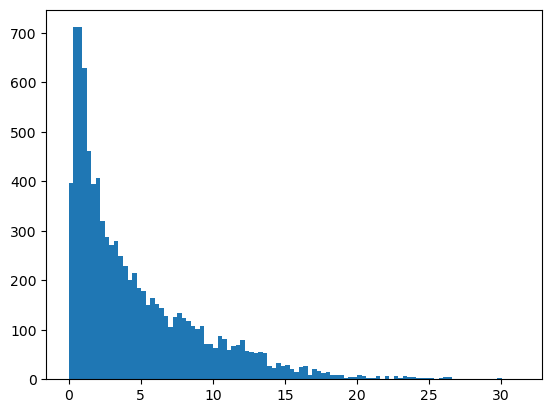

mean: 4.661532858716379, std: 4.5357214686769565, max: 31.28508303692826


In [13]:
all_err = []
frame_cnt, pt_cnt = pred_result_interpolated.shape[:2]
for frame_idx in range(frame_cnt):
    for pt_idx in range(pt_cnt):
        if id_missing_mask[frame_idx, pt_idx] == 1:
            min_dist = np.min(np.linalg.norm(pred_result_interpolated[frame_idx, pt_idx] - gt_pts[frame_idx], axis=1))
            all_err.append(min_dist)
all_err = np.array(all_err)
plt.hist(all_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_err)}, std: {np.std(all_err)}, max: {np.max(all_err)}')


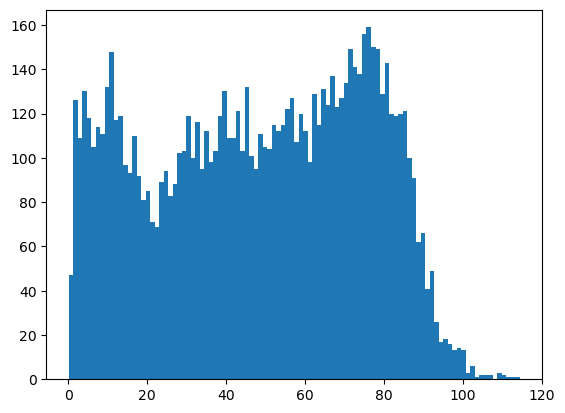

mean: 48.143761273682856, std: 26.7252779471961, max: 114.44609287780244


In [9]:
all_interp_err = np.linalg.norm((pred_result_polar_interpolated - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

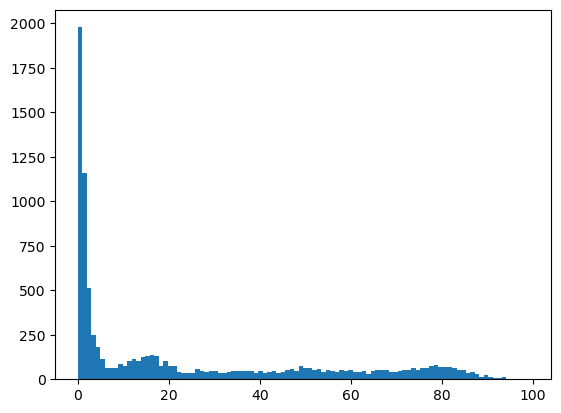

mean: 24.49698085570203, std: 28.573398369700936, max: 99.09608465416335


In [23]:
all_interp_err = np.linalg.norm((pred_result_interpolated - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

In [14]:
pred_result_interpolated_poly = polygon_correction_with_points(pred_result_interpolated)

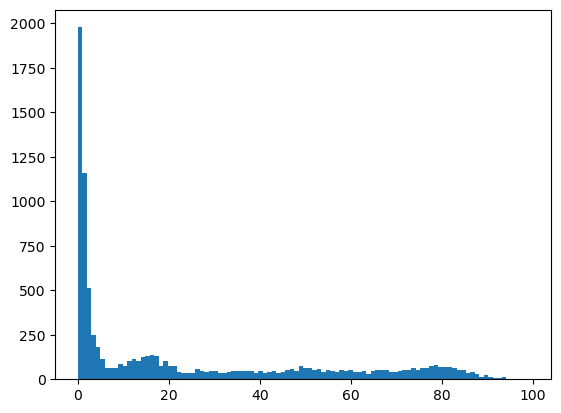

mean: 24.49698085570203, std: 28.573398369700936, max: 99.09608465416335


In [11]:
all_interp_err = np.linalg.norm((pred_result_w_ids - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

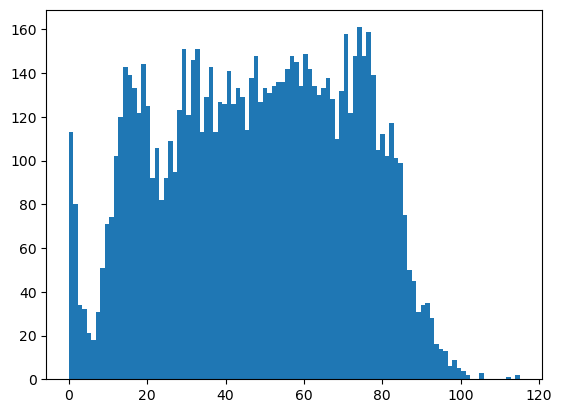

mean: 48.064415787610244, std: 23.871785160551237, max: 115.06862945150792


In [15]:
all_interp_err = np.linalg.norm((pred_result_interpolated_poly - gt_pts)[pred_missing_mask > 0], axis=1)
plt.hist(all_interp_err.flatten(), bins=100)
plt.show()
print(f'mean: {np.mean(all_interp_err)}, std: {np.std(all_interp_err)}, max: {np.max(all_interp_err)}')

In [13]:
vid_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/animal_1_1h_20s.mp4'
vid = video_loader(vid_path)
print(vid.shape, vid.min(), vid.max())

(3000, 170, 174) 0.00784313725490196 1.0


INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/polar_interp_test_animation.mp4
Animation saved to /home/mingxiao/Desktop/animation/polar_interp_test_animation.mp4


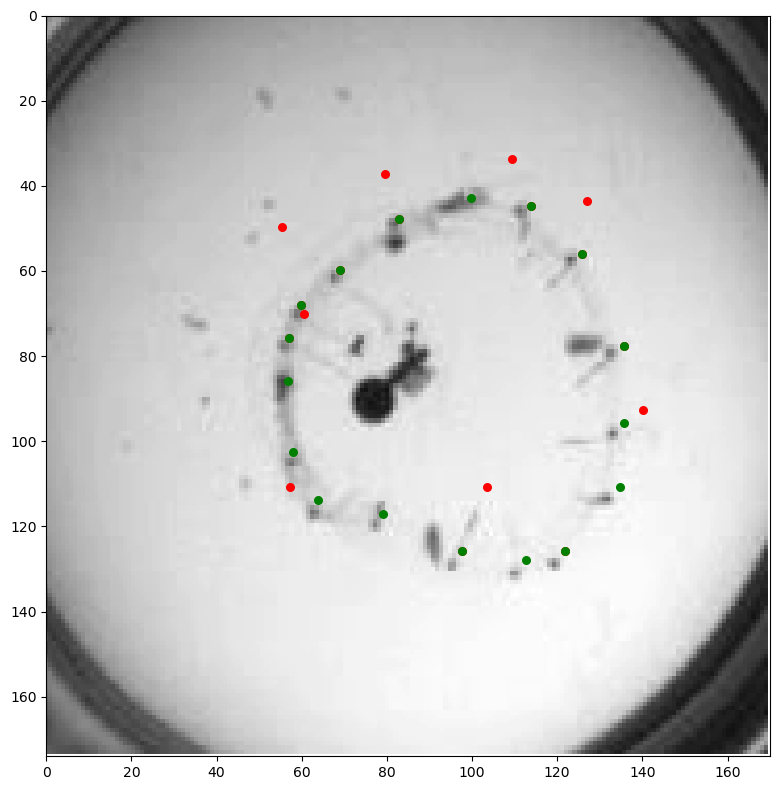

In [16]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}
interp_test_animation_path = '/home/mingxiao/Desktop/animation/polar_interp_test_animation.mp4'
animate_classification_results(pred_result_polar_interpolated, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                               bg_video=vid, bg_video_start_idx=0)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/interp_test_animation.mp4
Animation saved to /home/mingxiao/Desktop/animation/interp_test_animation.mp4


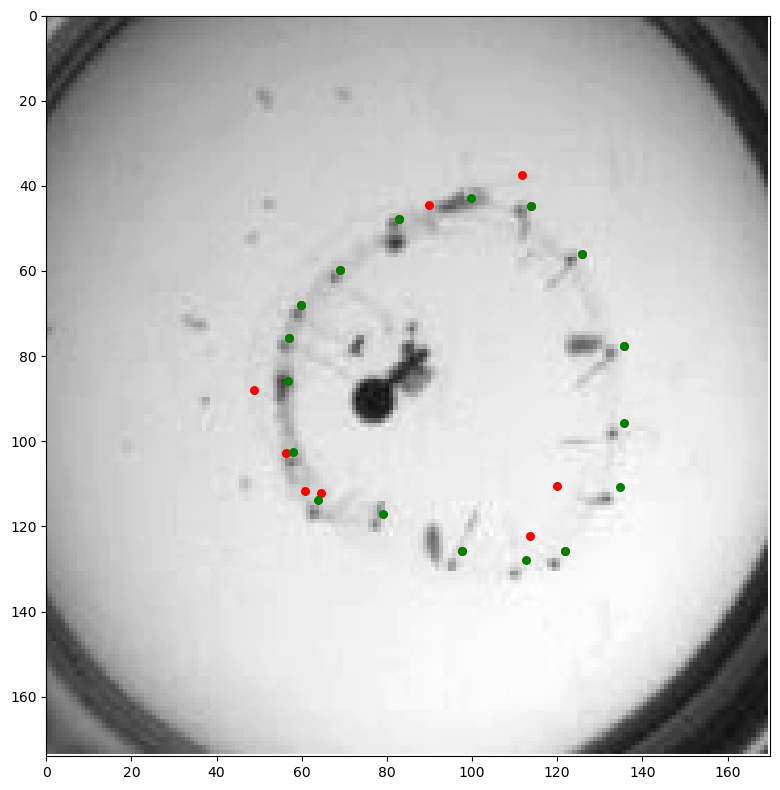

In [19]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}
interp_test_animation_path = '/home/mingxiao/Desktop/animation/interp_test_animation.mp4'
animate_classification_results(pred_result_interpolated, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                               bg_video=vid, bg_video_start_idx=0)

INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/interp_test_animation_id_assigned_only.mp4
Animation saved to /home/mingxiao/Desktop/animation/interp_test_animation_id_assigned_only.mp4


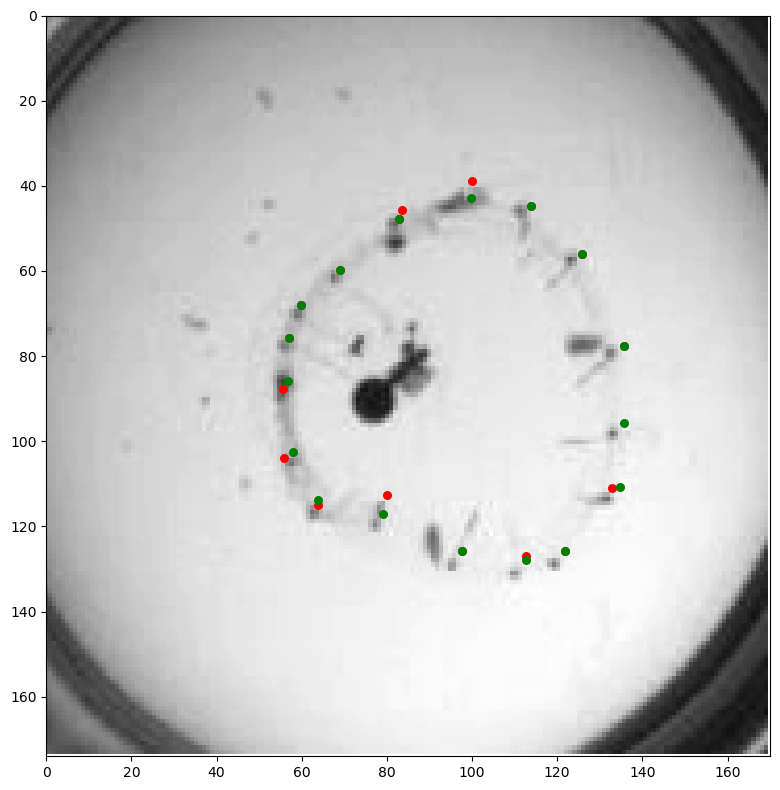

In [20]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}
interp_test_animation_path = '/home/mingxiao/Desktop/animation/interp_test_animation_id_assigned_only.mp4'
animate_classification_results(pred_result_w_ids, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                               bg_video=vid, bg_video_start_idx=0)

In [ ]:
m = np.zeros_like(id_missing_mask)
text_dict = {0: ''}

results_affix = ['m10t1', 'm10t2', 'm10t3', 'm11t1', 'm11t2']
all_predicted_pointss = []
results_dir = '/home/mingxiao/Desktop/jelly-sleap/sleap/jelly/autoencoder/results/r5'
existing_results = os.listdir(results_dir)
for affix in results_affix:
    print(f'affix: {affix}')
    denoised_coords = np.load(os.path.join(results_dir, f'prediction_{affix}.npy'))
    print(denoised_coords.shape)
    interp_test_animation_path = f'/home/mingxiao/Desktop/animation/r5/ae_result_{affix}.mp4'
    animate_classification_results(denoised_coords, gt_pts, m, output_path=interp_test_animation_path, text_dict=text_dict, 
                                   bg_video=vid, bg_video_start_idx=0)

affix: m10t1
(3000, 17, 2)
INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
INFO:matplotlib.animation:MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 800x800 -pix_fmt rgba -r 50 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/mingxiao/Desktop/animation/r5/ae_result_m10t1.mp4
